In [6]:
import json
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch
import torch.nn as nn

# ----------------------------
# Load target scaler (as before)
# ----------------------------
with open('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/scalers_and_data/scaler_y_0_025eV.json', 'r') as f:
    scaler_params = json.load(f)

scaler_y = MinMaxScaler(feature_range=tuple(scaler_params['feature_range']))
scaler_y.min_        = np.array(scaler_params['min_'])
scaler_y.scale_      = np.array(scaler_params['scale_'])
scaler_y.data_min_   = np.array(scaler_params['data_min_'])
scaler_y.data_max_   = np.array(scaler_params['data_max_'])
scaler_y.data_range_ = np.array(scaler_params['data_range_'])

# ----------------------------
# Device
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ----------------------------
# Inverse scaler (same API)
# ----------------------------
class InverseScaler(nn.Module):
    def __init__(self, feature_range, data_min, data_range):
        super().__init__()
        feature_min, feature_max = feature_range
        a = data_range / (feature_max - feature_min)
        b = (-feature_min * a) + data_min
        self.register_buffer('a_tensor', torch.tensor(a, dtype=torch.float32))
        self.register_buffer('b_tensor', torch.tensor(b, dtype=torch.float32))
    def forward(self, x):
        return x * self.a_tensor + self.b_tensor

# ----------------------------
# Max-Affine predictor (hard max)
# y(x) = max_j (w_j^T x + b_j)
# ----------------------------
class MaxAffine(nn.Module):
    def __init__(self, W, b):
        super().__init__()
        # W: [K, d], b: [K]
        # Store as Parameters for convenience (eval mode by default)
        self.W = nn.Parameter(W, requires_grad=False)
        self.b = nn.Parameter(b, requires_grad=False)
    def forward(self, x):
        # x: [N, d] (same feature layout you already use)
        z = x @ self.W.t() + self.b[:, None]   # [N, K]
        y = z.max(dim=1).values.view(-1, 1)    # [N, 1]
        return y

# ----------------------------
# Wrapper to match your "combined_model" name
# ----------------------------
class DeepSetWithInverseScaling(nn.Module):
    # Keep this class name to avoid changing downstream code
    def __init__(self, original_model, scaler_params):
        super().__init__()
        self.original_model = original_model
        feature_range = scaler_params['feature_range']
        data_min = scaler_params['data_min_'][0]
        data_range = scaler_params['data_range_'][0]
        self.inverse_scaler = InverseScaler(feature_range, data_min, data_range)
    def forward(self, x):
        scaled_output = self.original_model(x)          # standardized [0,1] target space
        inverse_scaled_output = self.inverse_scaler(scaled_output)  # back to eV
        return inverse_scaled_output

# ----------------------------
# Load OH_elements / p_dict_oh (as before)
# ----------------------------
with open('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/other_data_and_plots/helper_objects/OH_elements.json', 'r') as file:
    OH_elements = json.load(file)
total_N_elements = len(OH_elements)

with open('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/other_data_and_plots/helper_objects/p_dict_oh.json', 'r') as file:
    p_dict_oh = json.load(file)

input_dim = len(p_dict_oh['H'])   # feature dimension

# ----------------------------
# Load max-affine weights
# Expecting a .pt saved as: torch.save({'W': tensor[K,d], 'b': tensor[K]}, path)
# ----------------------------
max_affine_path = '/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/other_data_and_plots/models/MA-7.pt'  # <-- set this
ckpt = torch.load(max_affine_path, map_location=device)

W = ckpt['W'].float().to(device)   # [K, d]
b = ckpt['b'].float().to(device)   # [K]

# Sanity check on dimensions
assert W.dim() == 2 and b.dim() == 1, "Checkpoint must contain W[K,d] and b[K]"
assert W.shape[1] == input_dim, f"Feature dim mismatch: W has d={W.shape[1]} but input_dim={input_dim}"

# ----------------------------
# Build models
# ----------------------------
# Max-affine predictor in standardized target space
model = MaxAffine(W, b).to(device)
model.eval()

# Prepare scaler params for inverse (same structure you used)
scaler_params_inverse = {
    'feature_range': scaler_y.feature_range,
    'data_min_': scaler_y.data_min_,
    'data_range_': scaler_y.data_range_
}

# Expose the SAME NAME used elsewhere in your code:
combined_model = DeepSetWithInverseScaling(model, scaler_params_inverse).to(device)
combined_model.eval()


Using device: cpu


DeepSetWithInverseScaling(
  (original_model): MaxAffine()
  (inverse_scaler): InverseScaler()
)

In [7]:
import re
import numpy as np
import torch
import json

features_tensor = torch.load('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/scalers_and_data/features_tensor_0_025eV.pt')
features_array = np.array(features_tensor)
counts = np.count_nonzero(features_array, axis=-1)
features_array = features_array[counts <= 2]
with open('/Users/justint/Library/CloudStorage/OneDrive-Personal/Desktop/Academic Stuff/Arias Research/Materials_NN/Paper_Materials_2025/all_final/other_data_and_plots/helper_objects/OH_elements.json', 'r') as file:
    OH_elements = json.load(file)

W = (ckpt['W'].float().to(device)).numpy()  # [K, d]
b = ckpt['b'].float().to(device).numpy()   # [1]

res_facets = features_array @ W.T
ind_facets = np.argmax(res_facets, axis=1)

def extract_compound(feature):
    compound = []
    for i in range(total_N_elements):
        if feature[i] != 0:
            element = OH_elements[i]
            amt = feature[i]
            compound.append(f"{element}{amt:2f}")
    return ''.join(compound)

compound_dict = {}
for (feature, ind) in zip(features_array, ind_facets):
    comp = extract_compound(feature)
    compound_dict[comp] = int(ind)

In [8]:
"""
Periodic Table Highlighter (matplotlib)
--------------------------------------
Now supports MULTIPLE groups (list of lists), each highlighted with its own color.

Changes requested:
✓ Different colors per group
✓ Darker outlines and element text
✓ Larger element names
✓ Remove unused empty squares above transition metals
✓ Remove "Lanthanides" / "Actinides" labels
✓ No title/legend; tight crop that fits the table nicely with minimal padding

CLI examples:
    # Single group (backward compatible)
    python periodic_highlighter.py "H,Be,B,Al,Si,Zn,Ga,Ge,In,Sn,Sb,Tl,Pb,Bi" -o one_group.png

    # Multiple groups (semicolon-separated groups, comma-separated symbols)
    python periodic_highlighter.py -g "H,Be; B,C,N,O; Zn,Ga,Ge,In,Sn,Sb,Tl,Pb,Bi" -o multi_groups.png \
        --colors "#fde68a,#fecaca,#bfdbfe" --fontsize 20 --dpi 300

Programmatic example:
    from periodic_highlighter import draw_periodic_groups
    groups = [["H","Be"], ["B","C","N","O"], ["Zn","Ga","Ge","In","Sn","Sb","Tl","Pb","Bi"]]
    draw_periodic_groups(groups, out_path="multi.png")
"""
from __future__ import annotations
import argparse
from typing import Iterable, Dict, Tuple, List, Set, Optional
import colorsys
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ------------------------------
# Periodic table layout (18 cols)
# ------------------------------
PT_LAYOUT: List[List[str]] = [
    # 1
    ["H",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "He"],
    # 2
    ["Li", "Be", "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "B",  "C",  "N",  "O",  "F",  "Ne"],
    # 3
    ["Na", "Mg", "",  "",  "",  "",  "",  "",  "",  "",  "",  "",  "Al", "Si", "P",  "S",  "Cl", "Ar"],
    # 4
    ["K",  "Ca", "Sc", "Ti", "V",  "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Ga", "Ge", "As", "Se", "Br", "Kr"],
    # 5
    ["Rb", "Sr", "Y",  "Zr", "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn", "Sb", "Te", "I",  "Xe"],
    # 6
    ["Cs", "Ba", "La", "Hf", "Ta", "W",  "Re", "Os", "Ir", "Pt", "Au", "Hg", "Tl", "Pb", "Bi", "Po", "At", "Rn"],
    # 7
    ["Fr", "Ra", "Ac", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds", "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og"],
    # spacer (visual gap between main block and f-block rows)
    ["" for _ in range(18)],
    # Lanthanides (period 6 f-block) starting under group 4 (index 3)
    ["", "", "", "Ce", "Pr", "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu", ""],
    # Actinides (period 7 f-block)
    ["", "", "", "Th", "Pa", "U",  "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm", "Md", "No", "Lr", ""],
]

# Build lookup table: symbol -> (row, col)
POS: Dict[str, Tuple[int, int]] = {}
for r, row in enumerate(PT_LAYOUT):
    for c, sym in enumerate(row):
        if sym:
            POS[sym] = (r, c)

ALL_SYMBOLS: Set[str] = set(POS.keys())

# Symbols that should always be rendered with the base (uncolored) fill
NOBLE_GASES = {"He", "Ne", "Ar", "Kr", "Xe", "Rn", "Og"}
WHITEN_ALWAYS = NOBLE_GASES | {"Fr", "Ra", "Po", "At"}

# ------------------------------
# Drawing functions
# ------------------------------

def draw_periodic_groups(groups: List[Iterable[str]], out_path: str = "periodic_highlight.png",
                         dpi: int = 240,
                         facecolor: str = "white",
                         base_color: str = "#f8fafc",
                         line_color: str = "#111827",
                         colors: Optional[List[str]] = None,
                         text_color: str = "#0b0f15",
                         fontsize: int = 24) -> None:
    """Render a periodic table and highlight *multiple* groups of elements.

    Args:
        groups: list of iterables of element symbols. Each inner list gets its own color.
        out_path: output filepath (PNG/PDF/SVG)
        dpi: image DPI for rasters
        facecolor, base_color, line_color, text_color: colors
        colors: list of hex colors for groups; if None, a distinct, colorblind‑friendly palette is used
        fontsize: element symbol font size
    Notes:
        • Darker outlines and larger text by default.
        • No empty placeholder squares above transition metals.
        • No Lanthanides/Actinides labels. No title. Tight crop with padding.
    """
    # Normalize groups
    norm_groups: List[List[str]] = []
    for g in groups:
        norm_groups.append([s.strip() for s in g if s and isinstance(s, str)])

        # Build an element -> color map
    palette = _make_palette(len(norm_groups), colors)

    # Map element -> color (later groups override earlier on conflicts)
    sym2color: Dict[str, str] = {}
    for gi, g in enumerate(norm_groups):
        col = palette[gi % len(palette)]
        for s in g:
            if s in ALL_SYMBOLS:
                sym2color[s] = col

    # Map element -> color (later groups override earlier on conflicts)
    sym2color: Dict[str, str] = {}
    for gi, g in enumerate(norm_groups):
        col = palette[gi % len(palette)]
        for s in g:
            if s in ALL_SYMBOLS:
                sym2color[s] = col

    # Figure/axes: fill canvas
    fig = plt.figure(figsize=(20, 12), dpi=dpi, facecolor=facecolor)
    ax = fig.add_axes([0.005, 0.005, 0.99, 0.99])
    ax.set_facecolor(facecolor)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    w, h = 1.0, 1.0

    # Bounds based only on occupied cells
    occupied: List[Tuple[int,int]] = [(r, c) for r, row in enumerate(PT_LAYOUT) for c, sym in enumerate(row) if sym]
    min_r = min(r for r, _ in occupied)
    max_r = max(r for r, _ in occupied)
    min_c = min(c for _, c in occupied)
    max_c = max(c for _, c in occupied)
    pad = 0.2
    ax.set_xlim(min_c - pad, max_c + 1 + pad)
    ax.set_ylim(min_r - pad, max_r + 1 + pad)
    ax.invert_yaxis()

    # Draw element cells only
    for r, row in enumerate(PT_LAYOUT):
        for c, sym in enumerate(row):
            if not sym:
                continue
            fc = sym2color.get(sym, base_color)
            if sym in WHITEN_ALWAYS:
                fc = base_color
            rect = Rectangle((c, r), w, h, facecolor=fc, edgecolor=line_color, linewidth=1.6)
            ax.add_patch(rect)
            ax.text(c + 0.5, r + 0.54, sym,
                    ha='center', va='center', fontsize=fontsize, color=text_color, family='DejaVu Sans', fontweight='bold')

    # Save tightly cropped
    ext = out_path.split('.')[-1].lower()
    save_kwargs = dict(bbox_inches='tight', pad_inches=0.05, facecolor=facecolor)
    if ext in {"png", "jpg", "jpeg", "pdf", "svg"}:
        fig.savefig(out_path, **save_kwargs)
    else:
        fig.savefig("periodic_highlight.png", **save_kwargs)
    plt.close(fig)


def draw_periodic(highlight: Iterable[str], out_path: str = "periodic_highlight.png", **kwargs) -> None:
    """Backward-compatible single-group API.
    Example: draw_periodic(["H","Be"], out_path="one_group.png")
    """
    draw_periodic_groups([list(highlight)], out_path=out_path, **kwargs)


# ------------------------------
# Palette helpers
# ------------------------------

def _rgb_to_hex(rgb: Tuple[float, float, float]) -> str:
    r, g, b = [int(round(255*x)) for x in rgb]
    return f"#{r:02x}{g:02x}{b:02x}"


def _evenly_spaced_hues(n: int, s: float = 0.65, v: float = 0.90, hue_offset: float = 0.0) -> List[str]:
    """Generate n distinct colors by evenly spacing hues (HSV -> hex). Avoids very pale yellows."""
    cols: List[str] = []
    for i in range(n):
        h = (hue_offset + i / max(n, 1)) % 1.0
        # avoid the ~60° yellow band for legibility by nudging hues near 1/6
        if abs(h - 1/6) < 0.04:
            h += 0.06
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        cols.append(_rgb_to_hex((r, g, b)))
    return cols


def _make_palette(n: int, user_colors: Optional[List[str]] = None) -> List[str]:
    """Return a list of n distinct, colorblind‑aware colors.
    Priority:
      1) If user provided colors, use them (and extend if short).
      2) Use Matplotlib's 'tab10' (10 very distinct), then 'tab20' (evens then odds).
      3) If still short, generate evenly spaced HSV hues (skipping pale yellow band).
    """
    base: List[str] = []

    if user_colors:
        base.extend(user_colors)

    try:
        import matplotlib.pyplot as _plt
        tab10 = _plt.get_cmap('tab10')
        tab20 = _plt.get_cmap('tab20')
        # tab10 first (colorblind‑friendly)
        base.extend([_rgb_to_hex(tab10(i)[:3]) for i in range(10)])
        # pick every other from tab20 to maximize separation, then the rest
        base.extend([_rgb_to_hex(tab20(i)[:3]) for i in range(0, 20, 2)])
        base.extend([_rgb_to_hex(tab20(i)[:3]) for i in range(1, 20, 2)])
    except Exception:
        # Fallback if colormaps not available
        pass

    if len(base) < n:
        base.extend(_evenly_spaced_hues(n - len(base)))

    return base[:n]


In [9]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ============================================================
# === 1. Define element categories ===========================
# ============================================================
alkali = {"H","Li","Na","K","Rb","Cs","Fr"}
alkaline = {"Be","Mg","Ca","Sr","Ba","Ra"}
alkali_alkaline = alkali | alkaline

TM = {
    "Sc","Ti","V","Cr","Mn","Y","Zr","Nb","Mo","Tc","Hf","Ta","W","Re",
    "Fe","Co","Ni","Cu","Zn","Ru","Rh","Pd","Ag","Cd",
    "Os","Ir","Pt","Au","Hg"
}

# Lanthanides + a few actinides treated as TM
lanthanides = {
    "La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy",
    "Ho","Er","Tm","Yb","Lu","Th","Pa","U"
}
TM = TM | lanthanides

early_p = {
    "B",  "Al", "Ga", "In", "Tl",   # group 13
    "C",  "Si", "Ge", "Sn", "Pb",   # group 14
}

late_p = {
    "N",  "P",  "As", "Sb", "Bi",   # group 15
    "S",  "O",  "Se", "Te", "Po",   # group 16
    "F",  "Cl", "Br", "I",  "At",   # group 17
}

CATEGORY_MAP = {}
for el in alkali_alkaline: CATEGORY_MAP[el] = "alkali_alkaline"
for el in TM:              CATEGORY_MAP[el] = "TM"          # d/f block
for el in early_p:         CATEGORY_MAP[el] = "early_p"
for el in late_p:          CATEGORY_MAP[el] = "late_p"

all_categories = ["alkali_alkaline", "TM", "early_p", "late_p"]

category_colors = {
    "alkali_alkaline": "#1565C0",
    "TM":              "#2E7D32",
    "early_p":         "#EF6C00",
    "late_p":          "#D32F2F",
}

# ============================================================
# === 2. Build concentration-weighted pair stats per facet ===
#      + category-level binary counts (global & per facet)
# ============================================================
K = res_facets.shape[1]

# element_cat_weight_by_facet[k][elem][cat] = sum of stoich fractions
#   for that element on facet k, where its partner is in category `cat`
element_cat_weight_by_facet = [dict() for _ in range(K)]

# element_total_weight[elem] = sum of stoich fractions of `elem`
#   over ALL binary materials in the dataset (all facets)
element_total_weight = {}

# category_total_binaries[cat] = # of binary *compounds* anywhere in dataset
#   that involve category `cat` (at least one element in that cat)
category_total_binaries = {cat: 0 for cat in all_categories}

# category_binaries_by_facet[k][cat] = # of binary compounds on facet k
#   that involve at least one element in category `cat`
category_binaries_by_facet = [
    {cat: 0 for cat in all_categories} for _ in range(K)
]

num_elements = len(OH_elements)

for feature, facet_idx in zip(features_array, ind_facets):
    # indices of elements present in this compound
    nz_idx = np.nonzero(feature)[0]
    if len(nz_idx) != 2:
        # Only count binaries for this visualization
        continue

    vals = feature[nz_idx].astype(float)
    total = vals.sum()
    if total <= 0:
        continue

    # Normalize to fractions (just in case features aren't already normalized)
    fracs = vals / total
    elems = [OH_elements[i] for i in nz_idx]

    # two-element binary
    e1, e2 = elems
    f1, f2 = fracs

    c1 = CATEGORY_MAP.get(e1)
    c2 = CATEGORY_MAP.get(e2)
    if c1 is None or c2 is None:
        continue

    # --- Global element totals (not used in new metric, but kept) ---
    element_total_weight[e1] = element_total_weight.get(e1, 0.0) + float(f1)
    element_total_weight[e2] = element_total_weight.get(e2, 0.0) + float(f2)

    # --- Per-facet category-partner weights (concentration-weighted) ---
    d = element_cat_weight_by_facet[facet_idx]

    # For e1, partner is in category c2 → add f1
    if e1 not in d:
        d[e1] = {cat: 0.0 for cat in all_categories}
    d[e1][c2] = d[e1].get(c2, 0.0) + float(f1)

    # For e2, partner is in category c1 → add f2
    if e2 not in d:
        d[e2] = {cat: 0.0 for cat in all_categories}
    d[e2][c1] = d[e2].get(c1, 0.0) + float(f2)

    # --- Category-level binary counts (unweighted, per material) ---
    cats_present = set([c1, c2])
    for cat in cats_present:
        category_total_binaries[cat] += 1
        category_binaries_by_facet[facet_idx][cat] += 1

# ============================================================
# === 2.5. Total w_{A,C} over all facets: sum_{f'} w_{A,C}^{f'} ==
# ============================================================
pair_totals_over_facets = {}  # pair_totals_over_facets[A][C] = sum_f w_{A,C}^f

for facet_idx in range(K):
    facet_dict = element_cat_weight_by_facet[facet_idx]
    for sym, cat_dict in facet_dict.items():
        if sym not in pair_totals_over_facets:
            pair_totals_over_facets[sym] = {cat: 0.0 for cat in all_categories}
        for cat, w in cat_dict.items():
            pair_totals_over_facets[sym][cat] = pair_totals_over_facets[sym].get(cat, 0.0) + float(w)

# ============================================================
# === 3. Helpers to merge facets into facet-groups ===========
# ============================================================
def merge_facet_weights(facet_indices, element_cat_weight_by_facet):
    """
    Sum concentration-weighted counts over a list of facets.

    Returns:
        merged: dict[element_symbol] -> dict[category] -> weight
    """
    merged = {}
    for k in facet_indices:
        d = element_cat_weight_by_facet[k]
        for sym, cat_dict in d.items():
            if sym not in merged:
                merged[sym] = {cat: 0.0 for cat in all_categories}
            for cat, w in cat_dict.items():
                merged[sym][cat] = merged[sym].get(cat, 0.0) + w
    return merged

def merge_category_counts(facet_indices, category_binaries_by_facet):
    """
    Sum category-level binary counts over a list of facets.

    Returns:
        merged_cat_counts: dict[category] -> int
    """
    merged = {cat: 0 for cat in all_categories}
    for k in facet_indices:
        d = category_binaries_by_facet[k]
        for cat, count in d.items():
            merged[cat] += count
    return merged

def draw_pair_scatter_for_facet(
    facet_idx: int,
    element_cat_weight: dict,
    category_colors: dict,
    out_path: str,
    dpi: int = 240,
    facecolor: str = "white",
    base_color: str = "#f8fafc",
    line_color: str = "#111827",
    text_color: str = "#0b0f15",
    fontsize: int = 24,
    alpha: float = 1.0,
    title: str | None = None,
    element_total_weight: dict | None = None,
    group_cat_counts: dict | None = None,
    category_total_binaries: dict | None = None,
    pair_totals_over_facets: dict | None = None,
):
    """
    Each element cell is split into 4 sub-boxes (one for each category).

    For element A, category C, and facet f we have a raw weight w_{A,C}^f:
        total stoichiometric weight of A in binaries whose partner lies in C
        and that are assigned to facet f.

    First:
        I_{A,C}^f = w_{A,C}^f / sum_{f'} w_{A,C}^{f'}.

    Then we rescale within each facet:
        I_{A,C}^f ← I_{A,C}^f / max_{A',C'} I_{A',C'}^f.

    So the brightest sub-square on that facet has intensity 1.
    """

    fig = plt.figure(figsize=(20, 12), dpi=dpi, facecolor=facecolor)
    ax = fig.add_axes([0.005, 0.005, 0.99, 0.99])
    ax.set_facecolor(facecolor)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    w, h = 1.0, 1.0

    # bounds from occupied PT cells
    occupied = [
        (r, c)
        for r, row in enumerate(PT_LAYOUT)
        for c, sym in enumerate(row)
        if sym
    ]
    min_r = min(r for r, _ in occupied)
    max_r = max(r for r, _ in occupied)
    min_c = min(c for _, c in occupied)
    max_c = max(c for _, c in occupied)
    pad = 0.2
    ax.set_xlim(min_c - pad, max_c + 1 + pad)
    ax.set_ylim(min_r - pad, max_r + 1 + pad)
    ax.invert_yaxis()

    # ---- Draw base cells and element labels ----
    for r, row in enumerate(PT_LAYOUT):
        for c, sym in enumerate(row):
            if not sym:
                continue

            fc = base_color
            if sym in WHITEN_ALWAYS:
                fc = base_color

            cat = CATEGORY_MAP.get(sym, None)
            if cat is not None:
                ec = category_colors.get(cat, line_color)
                lw = 5.5
            else:
                ec = line_color
                lw = 1.5

            rect = Rectangle((c, r), w, h, facecolor=fc, edgecolor=ec, linewidth=lw)
            ax.add_patch(rect)
            ax.text(
                c + 0.5,
                r + 0.54,
                sym,
                ha='center',
                va='center',
                fontsize=fontsize,
                color=text_color,
                family='DejaVu Sans',
                fontweight='bold'
            )

    sub_w = w / 2.0
    sub_h = h / 2.0

    # --------------------------------------------------------
    # First pass: compute I_{A,C}^f = w_{A,C}^f / sum_{f'} w_{A,C}^{f'}
    # and track max intensity on this facet
    # --------------------------------------------------------
    combined_map = {}  # combined_map[sym][cat] = I_{A,C}^f
    max_intensity_on_facet = 0.0

    for sym, cat_weights in element_cat_weight.items():
        if sym not in POS:
            continue

        for cat in all_categories:
            w_val = cat_weights.get(cat, 0.0)
            if w_val <= 0.0:
                continue

            if pair_totals_over_facets is None:
                continue

            total_over_facets = pair_totals_over_facets.get(sym, {}).get(cat, 0.0)
            if total_over_facets <= 0.0:
                continue

            intensity = w_val / total_over_facets  # in [0,1] for given (A,C)

            if sym not in combined_map:
                combined_map[sym] = {}
            combined_map[sym][cat] = float(intensity)

            if intensity > max_intensity_on_facet:
                max_intensity_on_facet = intensity

    # If everything is zero, just save the blank PT
    if (not combined_map) or (max_intensity_on_facet <= 0.0):
        if title is None:
            title = f"Facet {facet_idx + 1}"
        ax.set_title(
            title,
            fontsize=40,
            fontweight="bold",
            color="#111827",
            pad=20
        )
        ext = out_path.split('.')[-1].lower()
        save_kwargs = dict(bbox_inches='tight', pad_inches=0.05, facecolor=facecolor)
        if ext in {"png", "jpg", "jpeg", "pdf", "svg"}:
            fig.savefig(out_path, **save_kwargs)
        else:
            fig.savefig("pair_scatter_facet.png", **save_kwargs)
        plt.close(fig)
        return

    # --------------------------------------------------------
    # Second pass: draw sub-squares using I_{A,C}^f / max_intensity_on_facet
    # --------------------------------------------------------
    min_alpha = 0.0
    max_alpha = 1.0

    for sym, cat_intensities in combined_map.items():
        if sym not in POS:
            continue

        r, c = POS[sym]

        for idx, cat in enumerate(all_categories):
            intensity = cat_intensities.get(cat, 0.0)
            if intensity <= 0.0:
                continue

            # facet-wise normalization
            frac = intensity / max_intensity_on_facet
            frac = max(0.0, min(1.0, frac))

            this_alpha = alpha * (min_alpha + (max_alpha - min_alpha) * frac)

            # Map idx → subcell position
            row_idx = 0 if idx < 2 else 1  # top/bottom
            col_idx = idx % 2              # left/right

            x0 = c + col_idx * sub_w
            y0 = r + row_idx * sub_h

            sub_rect = Rectangle(
                (x0, y0),
                sub_w,
                sub_h,
                facecolor=category_colors.get(cat, "#000000"),
                edgecolor='none',
                alpha=this_alpha
            )
            ax.add_patch(sub_rect)

    if title is None:
        title = f"Facet {facet_idx + 1}"

    ax.set_title(
        title,
        fontsize=40,
        fontweight="bold",
        color="#111827",
        pad=20
    )

    ext = out_path.split('.')[-1].lower()
    save_kwargs = dict(bbox_inches='tight', pad_inches=0.05, facecolor=facecolor)
    if ext in {"png", "jpg", "jpeg", "pdf", "svg"}:
        fig.savefig(out_path, **save_kwargs)
    else:
        fig.savefig("pair_scatter_facet.png", **save_kwargs)
    plt.close(fig)


# ============================================================
# === 5. Make plots for each facet individually ==============
# ============================================================
import os
os.makedirs("plots/pair_scatter_facets", exist_ok=True)

for facet_idx in range(K):
    # Per-facet element-category weights
    elem_weights = element_cat_weight_by_facet[facet_idx]

    group_cat_counts = category_binaries_by_facet[facet_idx]

    facet_label = facet_idx + 1  # make it 1-based for title/filename
    title = f"Facet {facet_label}"
    out_path = f"plots/pair_scatter_facets/pair_scatter_facet_{facet_label:02d}.png"

    draw_pair_scatter_for_facet(
        facet_idx=facet_idx,
        element_cat_weight=elem_weights,
        category_colors=category_colors,
        out_path=out_path,
        title=title,
        element_total_weight=element_total_weight,
        group_cat_counts=group_cat_counts,
        category_total_binaries=category_total_binaries,
        pair_totals_over_facets=pair_totals_over_facets,
        fontsize=36
    )

    print(
        f"Saved facet-normalized periodic table "
        f"for facet {facet_label} to {out_path}"
    )


Saved facet-normalized periodic table for facet 1 to plots/pair_scatter_facets/pair_scatter_facet_01.png
Saved facet-normalized periodic table for facet 2 to plots/pair_scatter_facets/pair_scatter_facet_02.png
Saved facet-normalized periodic table for facet 3 to plots/pair_scatter_facets/pair_scatter_facet_03.png
Saved facet-normalized periodic table for facet 4 to plots/pair_scatter_facets/pair_scatter_facet_04.png
Saved facet-normalized periodic table for facet 5 to plots/pair_scatter_facets/pair_scatter_facet_05.png
Saved facet-normalized periodic table for facet 6 to plots/pair_scatter_facets/pair_scatter_facet_06.png
Saved facet-normalized periodic table for facet 7 to plots/pair_scatter_facets/pair_scatter_facet_07.png


Class totals: [2064   82  570  327  662  905  101]
Row-normalized fractions (class × facet):
[[0.61579457 0.         0.00532946 0.         0.13468992 0.12354651
  0.12063953]
 [0.01219512 0.56097561 0.1097561  0.14634146 0.02439024 0.02439024
  0.12195122]
 [0.0122807  0.08947368 0.50350877 0.         0.26666667 0.11578947
  0.0122807 ]
 [0.00611621 0.15902141 0.13455657 0.59327217 0.04892966 0.01529052
  0.04281346]
 [0.23867069 0.00906344 0.0347432  0.         0.50151057 0.08912387
  0.12688822]
 [0.15469613 0.02872928 0.0519337  0.         0.00331492 0.5160221
  0.24530387]
 [0.13861386 0.11881188 0.00990099 0.         0.01980198 0.18811881
  0.52475248]]


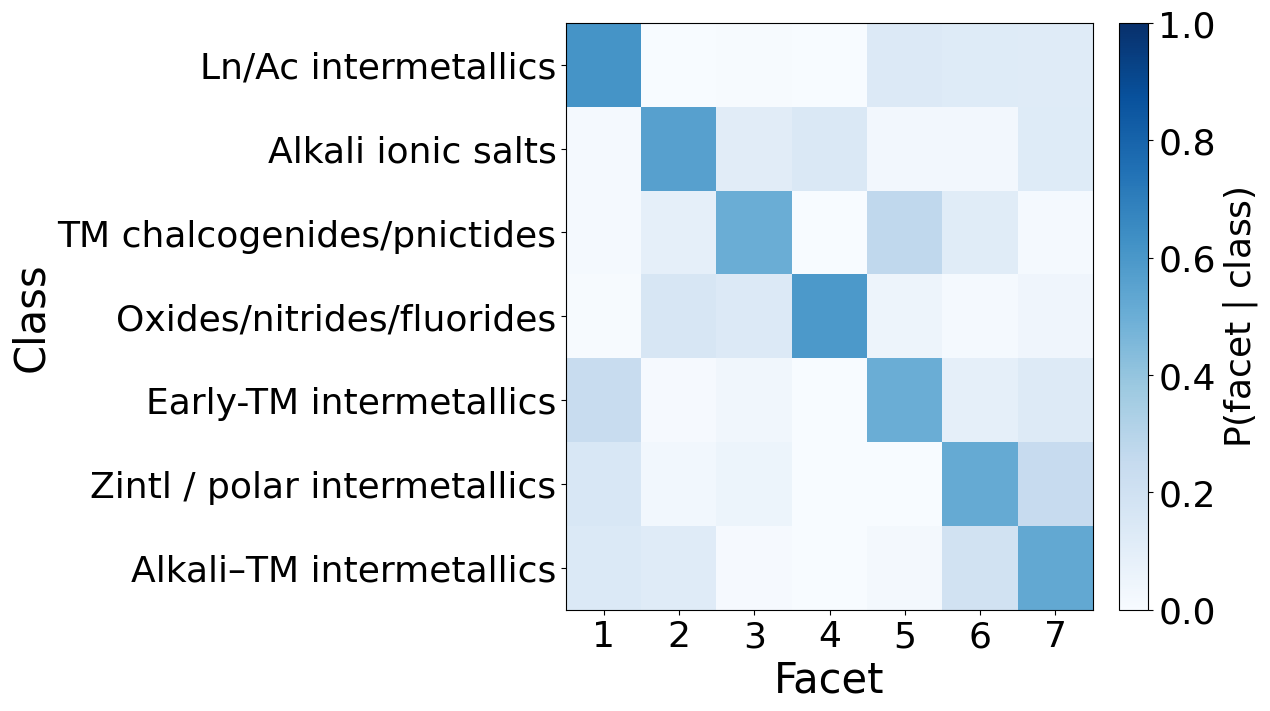

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Element sets
# ---------------------------------------------------------------

# s-block (separate out the alkalis used in some rules)
alkali   = {"Li", "Na", "K", "Rb", "Cs"}
alkaline = {"Be", "Mg", "Ca", "Sr", "Ba", "Ra"}
s_block  = alkali | alkaline | {"H", "Fr"}

big_s = {"Li", "Na", "K", "Rb", "Cs", "Ca", "Sr", "Ba"}

# d-block transition metals
TM = {
    "Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn",
    "Y","Zr","Nb","Mo","Tc","Ru","Rh","Pd","Ag","Cd",
    "Hf","Ta","W","Re","Os","Ir","Pt","Au","Hg"
}

early_tm = {"Sc","Ti","V","Cr","Y","Zr","Nb","Mo","Hf","Ta","W"}
late_tm  = TM - early_tm

# lanthanides / actinides
lanthanides = {
    "La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy",
    "Ho","Er","Tm","Yb","Lu"
}
actinides = {
    "Ac","Th","Pa","U","Np","Pu","Am","Cm","Bk","Cf",
    "Es","Fm","Md","No","Lr"
}
lanth_act = lanthanides | actinides

# p-block subsets
early_p = {"B","Al","Ga","In","Tl","C","Si","Ge","Sn","Pb"}
late_p  = {
    "N","P","As","Sb","Bi",
    "O","S","Se","Te",
    "F","Cl","Br","I"
}
p_block = early_p | late_p

# anion groups
light_anions = {"O", "N", "F"}
heavy_ch     = {"S", "Se", "Te"}
heavy_pn     = {"P", "As", "Sb", "Bi"}
halogens     = {"F", "Cl", "Br", "I"}

heavy_ch_pn  = heavy_ch | heavy_pn
all_anions   = light_anions | heavy_ch | halogens | heavy_pn

# group-13/14 p-metals often involved in Zintl / polar phases
zintl_p = {"Al","Ga","In","Tl","Si","Ge","Sn","Pb"}

# ---------------------------------------------------------------
# 2. Class names (short, for plotting)
# ---------------------------------------------------------------
class_names = [
    "Ln/Ac intermetallics",
    "Alkali ionic salts",
    "TM chalcogenides/pnictides",
    "Oxides/nitrides/fluorides",
    "Early-TM intermetallics",
    "Zintl / polar intermetallics",
    "Alkali–TM intermetallics",
]
n_classes = len(class_names)

# ---------------------------------------------------------------
# 3. Classifier
# ---------------------------------------------------------------
def is_p_block(el: str) -> bool:
    return el in p_block

def classify_pair(e1: str, e2: str):
    """
    Return class index 0–6 or None.
    The logic is ordered from most specific to more generic classes.
    """
    es = {e1, e2}

    # 0: Ln/Ac intermetallics (Ln/Ac + metal, no strong anions)
    if ((e1 in lanth_act or e2 in lanth_act)
        and not any(x in all_anions for x in es)):
        return 0

    # 1: alkali ionic salts (A–O/N/S/Se/F/Cl/Br, no TM or Ln/Ac)
    if ((e1 in alkali and e2 in {"O","N","S","Se","F","Cl","Br"}) or
        (e2 in alkali and e1 in {"O","N","S","Se","F","Cl","Br"})):
        if not (e1 in TM or e2 in TM or e1 in lanth_act or e2 in lanth_act):
            return 1

    # 2: TM + heavy chalcogenide / pnictide
    if ((e1 in TM and e2 in heavy_ch_pn) or
        (e2 in TM and e1 in heavy_ch_pn)):
        return 2

    # 3: oxides / nitrides / fluorides of p-block or TM cations
    if ((e1 in light_anions and (is_p_block(e2) or e2 in TM)
         and e2 not in big_s and e2 not in lanth_act) or
        (e2 in light_anions and (is_p_block(e1) or e1 in TM)
         and e1 not in big_s and e1 not in lanth_act)):
        return 3

    # 4: early-TM-centred intermetallics (no anions, not Zintl p-metals)
    if (any(x in early_tm for x in es)
        and not any(x in all_anions for x in es)
        and not any(x in zintl_p for x in es)):
        return 4

    # 5: early-p–rich Zintl / polar intermetallics
    if (
        (e1 in early_p and e2 in s_block) or
        (e2 in early_p and e1 in s_block) or
        (e1 in early_p and e2 in late_tm) or
        (e2 in early_p and e1 in late_tm) or
        (e1 in s_block and e2 in heavy_pn) or
        (e2 in s_block and e1 in heavy_pn) or
        (e1 in early_p and e2 in heavy_pn) or
        (e2 in early_p and e1 in heavy_pn) or
        (e1 in early_p and e2 in early_p)
    ):
        return 5

    # 6: alkali–TM / alkali–alkali metallic intermetallics
    if (not any(x in all_anions for x in es)
        and not any(is_p_block(x) for x in es)
        and not any(x in lanth_act for x in es)):

        # alkali + TM
        if ((e1 in alkali and e2 in TM) or
            (e2 in alkali and e1 in TM)):
            return 6

        # alkali + alkali
        if len(es) == 2 and all(x in alkali for x in es):
            return 6

    # everything else: unclassified / mixed
    return None

# ---------------------------------------------------------------
# 4. Build class × facet count matrix
# ---------------------------------------------------------------
class_facet_counts = np.zeros((n_classes, K), dtype=int)
class_totals = np.zeros(n_classes, dtype=int)

for feat, facet in zip(features_array, ind_facets):
    idx = np.nonzero(feat)[0]
    if len(idx) != 2:
        continue  # safety

    e1 = OH_elements[idx[0]]
    e2 = OH_elements[idx[1]]

    cls = classify_pair(e1, e2)
    if cls is None:
        continue  # skip ambiguous binaries

    class_facet_counts[cls, facet] += 1
    class_totals[cls] += 1

# ---------------------------------------------------------------
# 5. Row-normalized fractions: P(facet | class)
# ---------------------------------------------------------------
fractions = np.zeros_like(class_facet_counts, dtype=float)
for c in range(n_classes):
    if class_totals[c] > 0:
        fractions[c, :] = class_facet_counts[c, :] / class_totals[c]

print("Class totals:", class_totals)
print("Row-normalized fractions (class × facet):")
print(fractions)

# ---------------------------------------------------------------
# 6. Heatmap: P(facet | class)
# ---------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

fig, ax = plt.subplots(
    figsize=(1.8 * K, 1.0 * n_classes),
    constrained_layout=True
)

im = ax.imshow(fractions, aspect='auto', cmap='Blues', vmin=0.0, vmax=1.0)

ax.set_xticks(np.arange(K))
ax.set_xticklabels([str(i+1) for i in range(K)], fontsize=26)
ax.set_xlabel("Facet", fontsize=30)

ax.set_yticks(np.arange(n_classes))
ax.set_yticklabels(class_names, fontsize=26)
ax.set_ylabel("Class", fontsize=30)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\mathrm{P(facet \mid class)}$", fontsize=26)
cbar.ax.tick_params(labelsize=26)

fig.savefig(
    "plots/pair_scatter_facets/facet_class_correlation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [11]:
# ============================================================
# Check which facet specific covalent / semiconducting binaries land on
# Uses existing notebook objects:
#   OH_elements, features_array, ind_facets
# Optional:
#   res_facets  (for facet score / margin info)
# ============================================================

import re
import numpy as np
from collections import defaultdict

# ------------------------------------------------------------
# 1. Helpers
# ------------------------------------------------------------
def parse_formula(formula: str):
    """
    Parse a simple binary chemical formula like:
        Si, Ge, GaAs, InP, ZnTe, CdP, Cd3P2, CdP2
    Returns:
        elems: list of element symbols in order of appearance
        counts: list of integer stoichiometric counts
    """
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula)
    if not tokens:
        raise ValueError(f"Could not parse formula: {formula}")

    elems = []
    counts = []
    for el, n in tokens:
        elems.append(el)
        counts.append(int(n) if n else 1)

    return elems, counts


def normalized_formula_vector(formula: str, OH_elements):
    """
    Convert formula -> composition vector in the OH_elements basis.
    """
    elems, counts = parse_formula(formula)
    vec = np.zeros(len(OH_elements), dtype=float)

    total = sum(counts)
    for el, c in zip(elems, counts):
        if el not in OH_elements:
            raise ValueError(f"Element {el} not found in OH_elements")
        vec[OH_elements.index(el)] = c / total

    return vec


def canonical_formula_from_vec(vec, OH_elements, tol=1e-12):
    """
    Make a readable composition string from a composition vector.
    For binaries, tries to convert to small integer stoichiometry.
    """
    idx = np.where(vec > tol)[0]
    elems = [OH_elements[i] for i in idx]
    vals = vec[idx]

    if len(idx) == 0:
        return "∅"

    if len(idx) == 1:
        return elems[0]

    # Try to identify a simple integer ratio
    # Search for small denominator multiplier
    best_mult = None
    best_err = 1e9
    best_ints = None

    for mult in range(1, 17):
        ints = np.round(vals * mult).astype(int)
        if ints.sum() == 0:
            continue
        approx = ints / ints.sum()
        err = np.max(np.abs(approx - vals))
        if err < best_err:
            best_err = err
            best_mult = mult
            best_ints = ints

    if best_ints is not None and best_err < 1e-6:
        # reduce gcd
        g = np.gcd.reduce(best_ints)
        best_ints = best_ints // g
        out = ""
        for el, n in zip(elems, best_ints):
            out += el if n == 1 else f"{el}{n}"
        return out

    # fallback
    return " + ".join([f"{el}:{v:.3f}" for el, v in zip(elems, vals)])


def binary_pair_from_formula(formula: str):
    elems, counts = parse_formula(formula)
    if len(elems) == 1:
        return tuple(sorted(elems))
    if len(elems) != 2:
        raise ValueError(f"{formula} is not unary/binary")
    return tuple(sorted(elems))


def dominant_facet_info(i):
    """
    Returns dominant facet and optional score information if res_facets exists.
    """
    facet = int(ind_facets[i])

    out = {"facet": facet}

    if "res_facets" in globals():
        scores = np.asarray(res_facets[i]).ravel()
        order = np.argsort(scores)[::-1]
        top1 = int(order[0])
        top2 = int(order[1]) if len(order) > 1 else None
        out["top1_score"] = float(scores[top1])
        out["top2_score"] = float(scores[top2]) if top2 is not None else np.nan
        out["margin"] = float(scores[top1] - scores[top2]) if top2 is not None else np.nan
    return out


# ------------------------------------------------------------
# 2. What to search
# ------------------------------------------------------------
# You can add/remove formulas here.
target_formulas = [
    "Si",
    "Ge",
    "GaAs",
    "InP",
    "ZnTe",
    "CdP",    # advisor wrote CdP; script will also show all Cd-P binaries in dataset
    "Cd3P2",
    "CdP2",
]

# ------------------------------------------------------------
# 3. Exact composition matches + pair-level fallback
# ------------------------------------------------------------
# Precompute useful lookup structures
all_binary_rows_by_pair = defaultdict(list)
all_exact_rows_by_formula = defaultdict(list)

for i, feat in enumerate(features_array):
    feat = np.asarray(feat).ravel()
    idx = np.where(feat > 1e-12)[0]

    if len(idx) == 0:
        continue

    # exact formula-style key
    formula_here = canonical_formula_from_vec(feat, OH_elements)
    all_exact_rows_by_formula[formula_here].append(i)

    # binary pair key
    if len(idx) == 2:
        elems = tuple(sorted([OH_elements[idx[0]], OH_elements[idx[1]]]))
        all_binary_rows_by_pair[elems].append(i)
    elif len(idx) == 1:
        # unary as a "pair" of one element for convenience
        elems = (OH_elements[idx[0]],)
        all_binary_rows_by_pair[elems].append(i)


def rows_matching_exact_formula(query_formula):
    qvec = normalized_formula_vector(query_formula, OH_elements)
    matches = []
    for i, feat in enumerate(features_array):
        feat = np.asarray(feat).ravel()
        if np.max(np.abs(feat - qvec)) < 1e-10:
            matches.append(i)
    return matches


def rows_matching_same_binary_pair(query_formula):
    elems, counts = parse_formula(query_formula)
    if len(elems) == 1:
        return all_binary_rows_by_pair.get((elems[0],), [])
    elif len(elems) == 2:
        return all_binary_rows_by_pair.get(tuple(sorted(elems)), [])
    else:
        return []


# ------------------------------------------------------------
# 4. Print report
# ------------------------------------------------------------
print("=" * 90)
print("FACET REPORT FOR REQUESTED SEMICONDUCTOR / COVALENT SYSTEMS")
print("=" * 90)

facet_summary_exact = defaultdict(int)
facet_summary_pair = defaultdict(int)

for formula in target_formulas:
    print(f"\n--- {formula} ---")

    # A. exact composition match
    exact_rows = rows_matching_exact_formula(formula)

    if len(exact_rows) > 0:
        print("Exact composition matches:")
        for i in exact_rows:
            info = dominant_facet_info(i)
            formula_here = canonical_formula_from_vec(features_array[i], OH_elements)
            line = f"  row {i:6d} | {formula_here:>8s} | facet {info['facet'] + 1}"
            if "top1_score" in info:
                line += (
                    f" | top score = {info['top1_score']:.6g}"
                    f" | margin = {info['margin']:.6g}"
                )
            print(line)
            facet_summary_exact[info["facet"]] += 1
    else:
        print("No exact composition match found.")

    # B. same binary pair fallback
    pair_rows = rows_matching_same_binary_pair(formula)
    if len(pair_rows) > 0:
        print("Same unary/binary element set present in dataset:")
        pair_bucket = defaultdict(list)
        for i in pair_rows:
            info = dominant_facet_info(i)
            formula_here = canonical_formula_from_vec(features_array[i], OH_elements)
            pair_bucket[info["facet"]].append((formula_here, i, info))

        for facet in sorted(pair_bucket):
            print(f"  Facet {facet + 1}:")
            for formula_here, i, info in pair_bucket[facet]:
                line = f"    row {i:6d} | {formula_here:>8s}"
                if "top1_score" in info:
                    line += (
                        f" | top score = {info['top1_score']:.6g}"
                        f" | margin = {info['margin']:.6g}"
                    )
                print(line)
                facet_summary_pair[facet] += 1
    else:
        print("No matching unary/binary pair found in dataset.")

# ------------------------------------------------------------
# 5. Compact summary
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("SUMMARY: exact queried compositions")
print("=" * 90)
if len(facet_summary_exact) == 0:
    print("No exact queried compositions were found.")
else:
    for facet in sorted(facet_summary_exact):
        print(f"Facet {facet + 1}: {facet_summary_exact[facet]} exact match(es)")

print("\n" + "=" * 90)
print("SUMMARY: all rows involving the same unary/binary element sets")
print("=" * 90)
if len(facet_summary_pair) == 0:
    print("No matching unary/binary systems were found.")
else:
    for facet in sorted(facet_summary_pair):
        print(f"Facet {facet + 1}: {facet_summary_pair[facet]} row(s)")

# ------------------------------------------------------------
# 6. Optional: group queried systems by dominant facet
#    This is nice if draw_periodic_groups(...) from your other cell is loaded.
# ------------------------------------------------------------
facet_to_elements = defaultdict(set)

for formula in target_formulas:
    exact_rows = rows_matching_exact_formula(formula)
    for i in exact_rows:
        idx = np.where(np.asarray(features_array[i]).ravel() > 1e-12)[0]
        facet = int(ind_facets[i])
        for j in idx:
            facet_to_elements[facet].add(OH_elements[j])

if "draw_periodic_groups" in globals() and len(facet_to_elements) > 0:
    groups = [sorted(list(facet_to_elements[f])) for f in sorted(facet_to_elements)]
    print("\nDrawing periodic table highlight for exact queried systems by facet...")
    draw_periodic_groups(
        groups,
        out_path="plots/pair_scatter_facets/queried_semiconductors_by_facet.png",
        fontsize=24,
        dpi=300
    )
    print("Saved: plots/pair_scatter_facets/queried_semiconductors_by_facet.png")

FACET REPORT FOR REQUESTED SEMICONDUCTOR / COVALENT SYSTEMS

--- Si ---
Exact composition matches:
  row     69 |       Si | facet 6 | top score = 0.514371 | margin = 0.310148
Same unary/binary element set present in dataset:
  Facet 6:
    row     69 |       Si | top score = 0.514371 | margin = 0.310148

--- Ge ---
Exact composition matches:
  row     27 |       Ge | facet 6 | top score = 0.53914 | margin = 0.14473
Same unary/binary element set present in dataset:
  Facet 6:
    row     27 |       Ge | top score = 0.53914 | margin = 0.14473

--- GaAs ---
Exact composition matches:
  row   1273 |     GaAs | facet 6 | top score = 0.448837 | margin = 0.0665166
Same unary/binary element set present in dataset:
  Facet 6:
    row   1273 |     GaAs | top score = 0.448837 | margin = 0.0665166

--- InP ---
Exact composition matches:
  row   2913 |      PIn | facet 6 | top score = 0.451202 | margin = 0.0574589
Same unary/binary element set present in dataset:
  Facet 6:
    row   2913 |      P